# 2. Vessel segmentation

The first stage turns the CTA into a binary vessel mask with nnU-Net. This notebook shows the two ways of running it, fast and full, and the head-and-neck split that the full mode relies on.

Expect a few minutes on a GPU. Everything is written to the notebook's own case directory.


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



(512, 512, 782) voxels at [0.54 0.54 0.4 ] mm


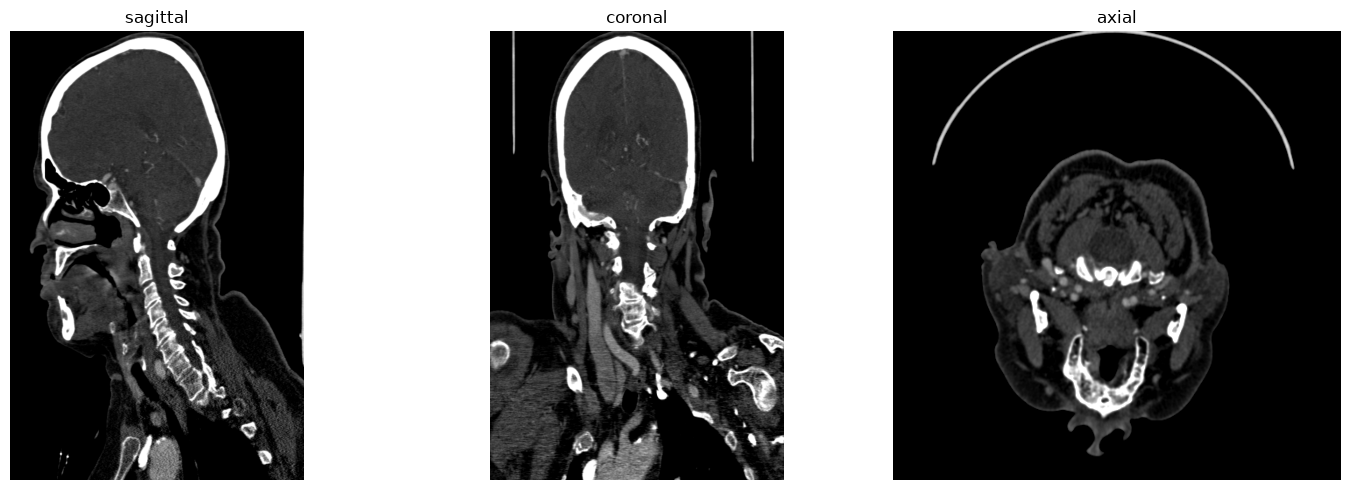

In [1]:
import numpy as np, nibabel as nib
from arterial_nb import *
from arterial.segmentation import utils as seg_utils
from arterial.segmentation.segmenter import VesselSegmenter

cta = nib.load(fixture("cta.nii.gz"))
cta_array = np.asarray(cta.dataobj)
print(cta.shape, "voxels at", np.round(np.abs(np.diag(cta.affine)[:3]), 2), "mm")
show_slices(cta_array, window=(-100, 600));

## Fast mode: one model, whole volume

Fast mode runs a single low-resolution model over the entire CTA. It is the setting used for extracranial work, where the neck vessels matter most.

fast segmentation: 42.6 s


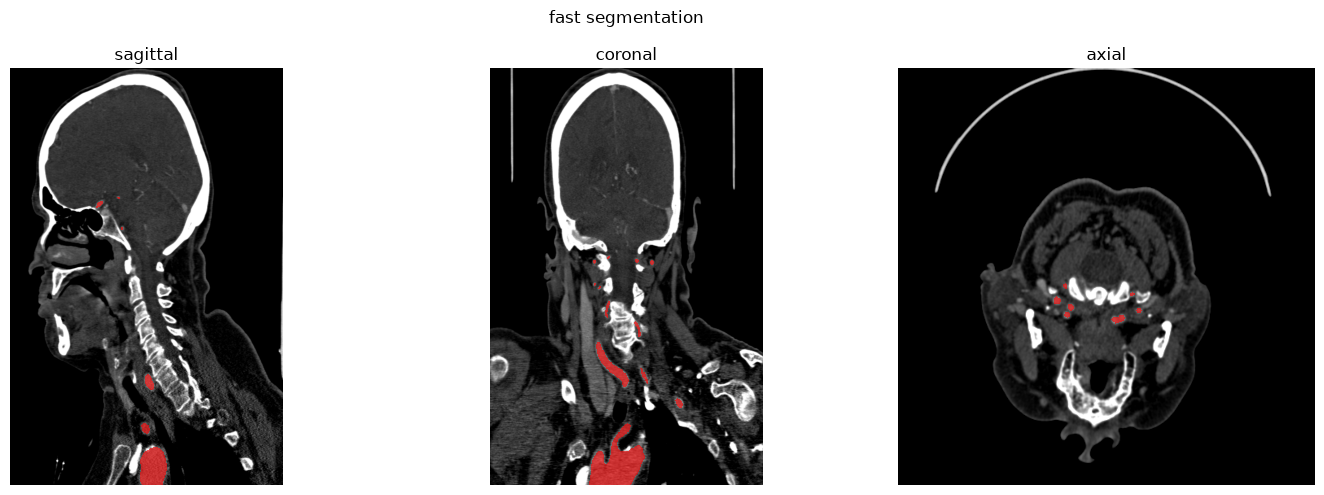

In [2]:
fast = VesselSegmenter(case("segmentation_fast"), MODE, fixture("cta.nii.gz"), fast_segmentation=True)
with timed("fast segmentation"), quiet():
    fast.segment_vessels_from_cta()
show_slices(cta_array, mask=fast.segmentation_array, window=(-100, 600), title="fast segmentation");

## Full mode: split the head from the neck

The intracranial vessels are thin and dense, the neck vessels large and sparse, so the full mode segments them with different models. It first needs to know where the skull starts. Two estimators exist: a Laplacian filter of the upper half of the CTA, and a TotalSegmentator model that segments the cranium.

laplacian cranium mask: 4.3 s


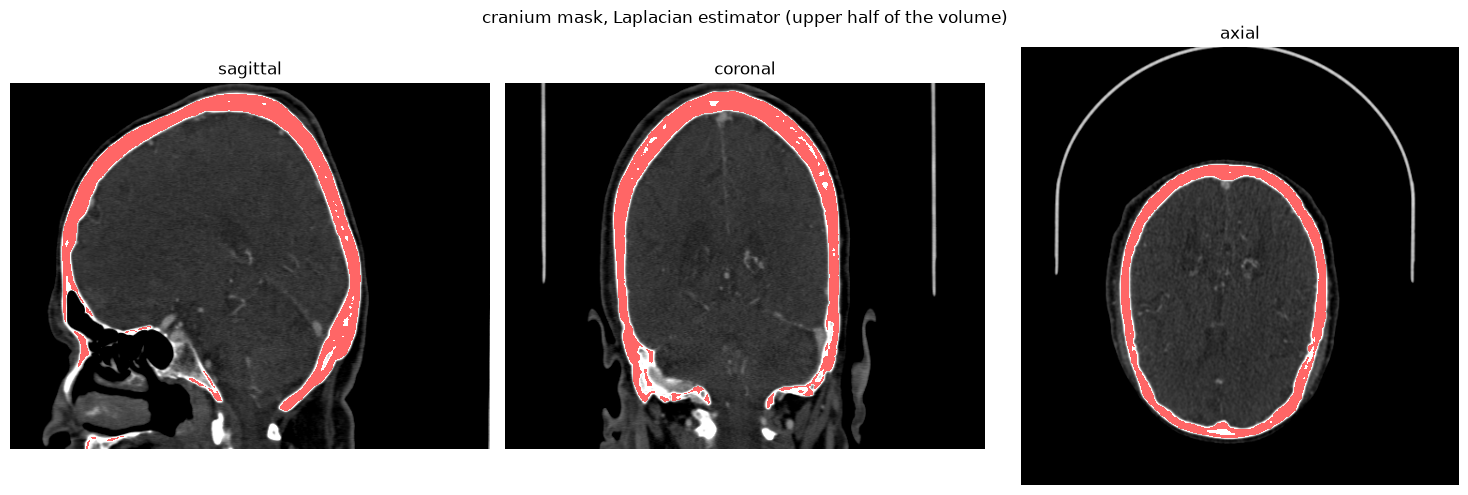

In [3]:
with timed("laplacian cranium mask"):
    cranium = seg_utils.compute_cranium_mask(cta_array)
upper_half = cta_array[:, :, cta_array.shape[2] // 2:]
show_slices(upper_half, mask=cranium, window=(-100, 600), title="cranium mask, Laplacian estimator (upper half of the volume)");

In [4]:
with timed("head/neck split (TotalSegmentator)"), quiet():
    head, neck, head_affine, bbox = seg_utils.slice_cta_head_and_neck(cta_array, cta.affine, return_bounding_box=True)
table([["whole CTA", *cta_array.shape], ["head slab", *head.shape], ["neck slab", *neck.shape]], columns=["volume", "R", "A", "S"])

head/neck split (TotalSegmentator): 59.7 s


,volume,R,A,S
0,whole CTA,512,512,782
1,head slab,250,329,384
2,neck slab,512,512,430


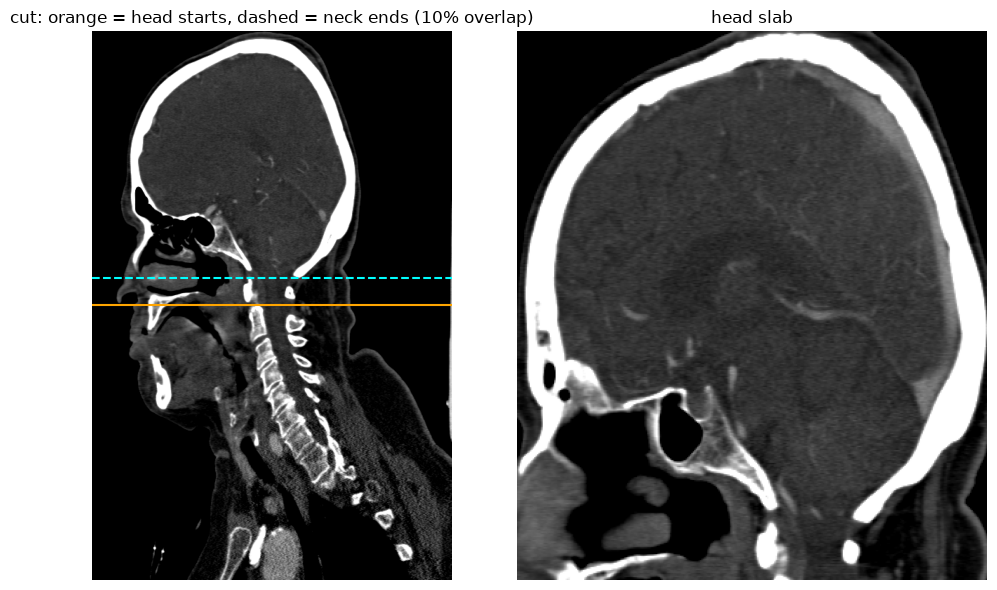

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
mid = cta_array.shape[0] // 2
axes[0].imshow(cta_array[mid].T, cmap="gray", origin="lower", vmin=-100, vmax=600)
axes[0].axhline(bbox[4], color="orange"); axes[0].axhline(int(1.1 * bbox[4]), color="cyan", linestyle="--")
axes[0].set_title("cut: orange = head starts, dashed = neck ends (10% overlap)"); axes[0].axis("off")
axes[1].imshow(head[head.shape[0] // 2].T, cmap="gray", origin="lower", vmin=-100, vmax=600); axes[1].set_title("head slab"); axes[1].axis("off")
plt.tight_layout(); show(fig);

The two segmentations overlap by ten percent of the neck height. They are joined at the slice where they agree best, measured with the Dice coefficient, so the seam does not cut through a vessel.

full segmentation (head + neck): 125.1 s


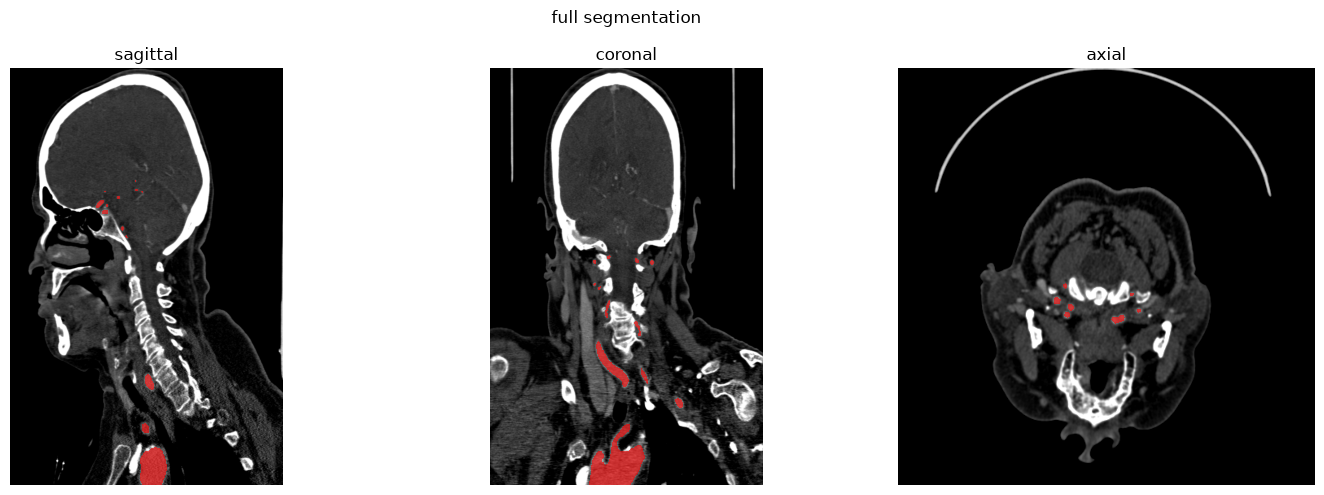

In [6]:
full = VesselSegmenter(case("segmentation_full"), MODE, fixture("cta.nii.gz"), fast_segmentation=False)
with timed("full segmentation (head + neck)"), quiet():
    full.segment_vessels_from_cta()
show_slices(cta_array, mask=full.segmentation_array, window=(-100, 600), title="full segmentation");

## Fast versus full

Both masks live on the CTA grid, so they compare voxel by voxel. The full mode finds more of the intracranial tree; the fast mode is quicker and enough for the neck.

In [7]:
a, b = fast.segmentation_array > 0, full.segmentation_array > 0
dice = 2 * np.logical_and(a, b).sum() / (a.sum() + b.sum())
voxel_mm3 = float(np.prod(np.abs(np.diag(cta.affine)[:3])))
table([["fast", int(a.sum()), round(a.sum() * voxel_mm3 / 1000, 1)], ["full", int(b.sum()), round(b.sum() * voxel_mm3 / 1000, 1)],
       ["Dice fast vs full", round(dice, 3), ""]], columns=["", "voxels", "volume (cm3)"])

,,voxels,volume (cm3)
0,fast,862350.000,101.7
1,full,887039.000,104.6
2,Dice fast vs full,0.972,


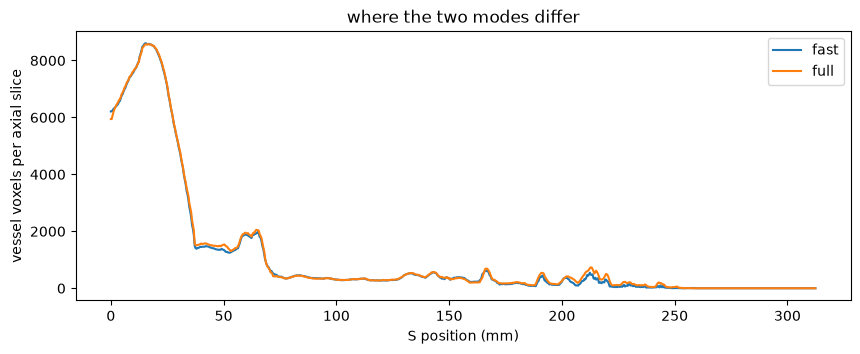

In [8]:
profile_fast = a.sum(axis=(0, 1)); profile_full = b.sum(axis=(0, 1))
z = np.arange(len(profile_fast)) * abs(cta.affine[2, 2])
plt.figure(figsize=(10, 3.5))
plt.plot(z, profile_fast, label="fast"); plt.plot(z, profile_full, label="full")
plt.xlabel("S position (mm)"); plt.ylabel("vessel voxels per axial slice"); plt.legend(); plt.title("where the two modes differ"); show(plt.gcf());

## Intracranial mode

Intracranial mode keeps only the head slab and runs the full-resolution model on it, so its output is a smaller volume in head-slab space with its own affine.

intracranial segmentation: 102.2 s
output shape (250, 329, 384) vs CTA (512, 512, 782)


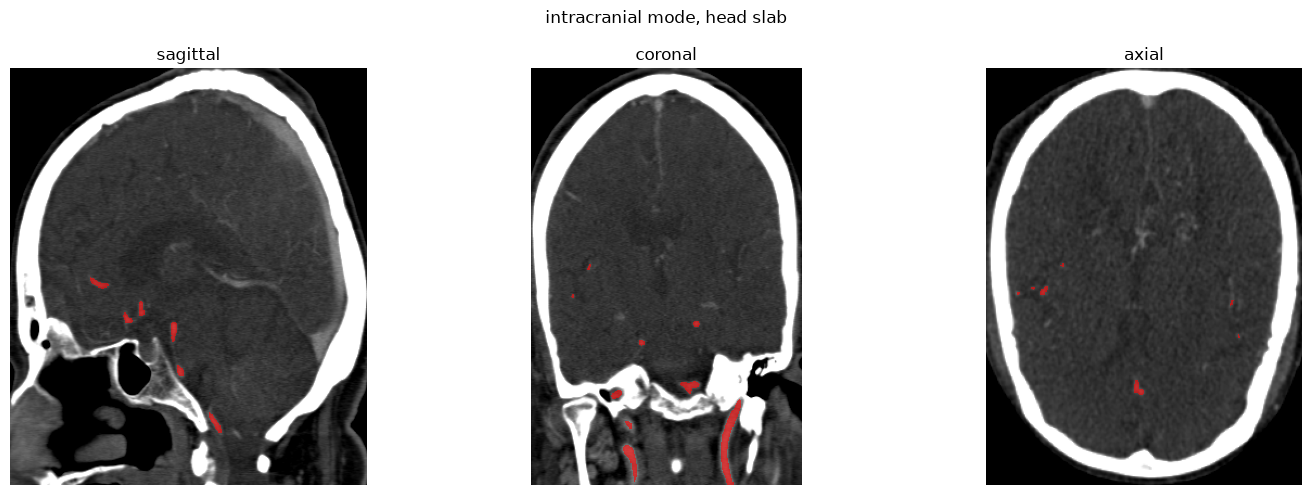

In [9]:
intra = VesselSegmenter(case("segmentation_intra"), "intracranial_vessels", fixture("cta.nii.gz"))
with timed("intracranial segmentation"), quiet():
    intra.segment_vessels_from_cta()
print("output shape", intra.segmentation_array.shape, "vs CTA", cta.shape)
show_slices(intra.cta_head_array, mask=intra.segmentation_array, window=(-100, 600), title="intracranial mode, head slab");

## What to check

- The mask should follow the aorta, both carotids and both vertebrals in the coronal view; a missing vertebral is the most common failure.
- The seam between head and neck should not leave a gap in the carotids at the skull base.
- A fast-mode volume far below the full-mode one on the neck usually means the CTA is not head-and-neck, or the orientation is unusual.